In [35]:
import sys
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import subprocess
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

### Datos del Problema (Caso 4)

**Tabla de Conectividad del Reticulado:**

| Barra | Nodo $i$ ($N_i$) | Nodo $j$ ($N_j$) |
|:---:|:---:|:---:|
| 1 | 1 | 3 |
| 2 | 3 | 4 |
| 3 | 4 | 1 |
| 4 | 4 | 2 |
| 5 | 2 | 5 |
| 6 | 5 | 4 |
| 7 | 3 | 8 |
| 8 | 8 | 9 |
| 9 | 9 | 5 |
| 10 | 8 | 4 |
| 11 | 4 | 9 |
| 12 | 8 | 10 |
| 13 | 10 | 9 |
| 14 | 9 | 7 |
| 15 | 8 | 6 |

**Parámetros Físicos y Geométricos:**

* **Densidad de la barra:** $\rho = 1$
* **Módulo de elasticidad longitudinal:** $E = 50$
* **Área de la sección transversal:** $A = 2$
* **Carga uniforme:** $P(t) = 10$

**Parámetros del Sistema Amortiguador (Parte C):**

* **Densidad del fluido:** $\rho_{fl} = 3.0$
* **Radio de la esfera amortiguadora:** $r_{esf} = 1.5$
* **Cota de la superficie libre del fluido:** $h_{SL} = 25$

**Elementos de Análisis (Parte B y C):**

* **Barra de análisis:** $a = 8$
* **Nodo de análisis de coordenadas:** $b = 10$
* **Nodo con amortiguador:** $c = 10$

![NuestroCaso](Imagenes/caso.png)

### Parte A: Cálculo de la Respuesta Dinámica

**Desarrolle un programa computacional** que calcule la respuesta dinámica del sistema ante una carga $P(t)$ definida por una función uniforme en el tiempo, en un periodo de tiempo de 0 a 50 segundos máximo ($t_{F\_Max}$). 


![grafica](Imagenes/grafica.png)


Considere dos situaciones:

**i. Fuerzas en la configuración deformada:** Que la dirección de las fuerzas sigue la dirección de las barras durante todo el proceso de deformación, es decir, el de las barras en la configuración deformada. 
> *Nota:* Esta condición está relacionada con lo que se conoce como **hipótesis de deformaciones finitas**, que se desarrolla en la cátedra en temas posteriores.

**ii. Fuerzas en la configuración de referencia:**
Que las fuerzas mantienen la dirección del reticulado no deformado, es decir, la de la configuración de referencia. 
> *Nota:* Acá se adopta una hipótesis simplificativa para la solución del problema que supone pequeños desplazamientos de los nodos y pequeños giros de las barras. Este tipo de hipótesis facilita la resolución del problema considerando que algunos términos son despreciables frente a otros. Razonamientos similares se emplean en la **hipótesis de deformaciones infinitesimales**, que también se desarrolla posteriormente en la cátedra.

In [36]:
def calcular_derivadas(t, Y):
    posiciones = Y[:num_gdl]
    velocidades = Y[num_gdl:]
    
    F_interna = np.zeros(num_gdl)
    
    for b in range(num_barras):
        nodo_i = conectividad[b, 0]
        nodo_j = conectividad[b, 1]
        
        xi_actual, yi_actual = posiciones[2*nodo_i], posiciones[2*nodo_i + 1]
        xj_actual, yj_actual = posiciones[2*nodo_j], posiciones[2*nodo_j + 1]
        
        dx_actual = xj_actual - xi_actual
        dy_actual = yj_actual - yi_actual
        
        # Agregamos un número pequeñísimo (1e-9) para evitar división por cero
        longitud_actual = np.sqrt(dx_actual**2 + dy_actual**2) + 1e-9
        
        # Rigidez axial según la ley de elasticidad [cite: 69, 74]
        fuerza_resorte = ((elasticidad * area) / L0[b]) * (longitud_actual - L0[b])
        
        Fx = fuerza_resorte * (dx_actual / longitud_actual)
        Fy = fuerza_resorte * (dy_actual / longitud_actual)
        
        F_interna[2*nodo_i]     += Fx
        F_interna[2*nodo_i + 1] += Fy
        F_interna[2*nodo_j]     -= Fx
        F_interna[2*nodo_j + 1] -= Fy
        
    F_neta = F_externa - F_interna
    F_neta[gdl_restringidos] = 0.0
    
    # Protección: Si la masa es 0 (no debería), usamos un valor muy grande para que no acelere
    # Esto evita el error de NaNs [cite: 231]
    aceleraciones = np.where(M_global > 0, F_neta / M_global, 0.0)
    
    return np.concatenate((velocidades, aceleraciones))

Simulando Modelo a.ii (Configuración de Referencia)...


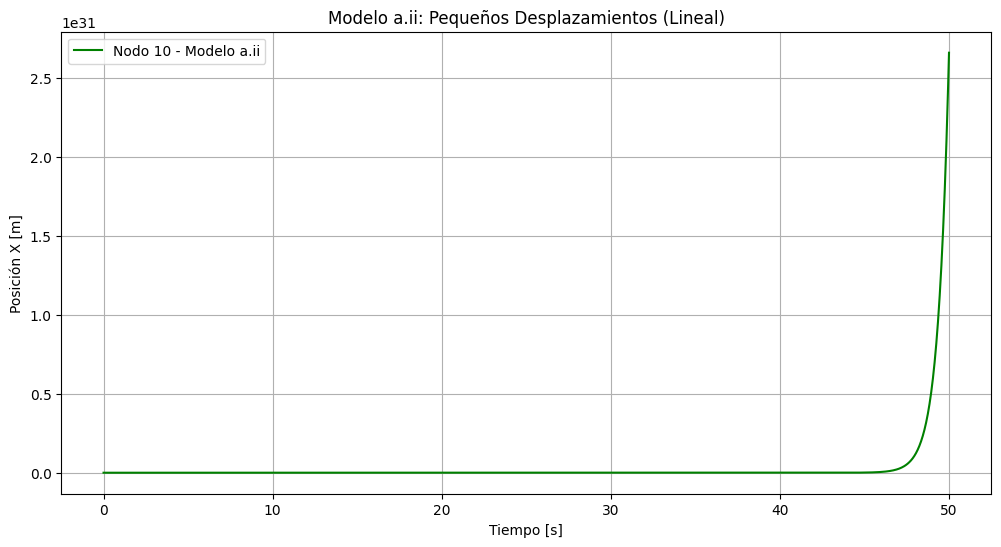

¡Listo! Chequeá la escala del eje Y ahora.


In [42]:
# --- 1. FUNCIÓN MOTOR MODELO A.II (PEQUEÑOS DESPLAZAMIENTOS) ---
def calcular_derivadas_pequenos(t, Y):
    posiciones = Y[:num_gdl]
    velocidades = Y[num_gdl:]
    
    # En este modelo, el desplazamiento es la clave
    desplazamientos = posiciones - coordenadas.flatten()
    F_interna = np.zeros(num_gdl)
    
    for b in range(num_barras):
        nodo_i = conectividad[b, 0]
        nodo_j = conectividad[b, 1]
        
        # USAMOS SIEMPRE LA GEOMETRÍA ORIGINAL (Referencia)
        xi, yi = coordenadas[nodo_i]
        xj, yj = coordenadas[nodo_j]
        dx = xj - xi
        dy = yj - yi
        L_orig = L0[b]
        
        # Cosenos y senos fijos
        cos = dx / L_orig
        sen = dy / L_orig
        
        # Proyectamos los desplazamientos sobre el eje de la barra
        du = desplazamientos[2*nodo_j] - desplazamientos[2*nodo_i]
        dv = desplazamientos[2*nodo_j+1] - desplazamientos[2*nodo_i+1]
        
        # El alargamiento es una aproximación lineal
        alargamiento = du * cos + dv * sen
        fuerza_resorte = ((elasticidad * area) / L_orig) * alargamiento
        
        Fx = fuerza_resorte * cos
        Fy = fuerza_resorte * sen
        
        F_interna[2*nodo_i]     += Fx
        F_interna[2*nodo_i + 1] += Fy
        F_interna[2*nodo_j]     -= Fx
        F_interna[2*nodo_j + 1] -= Fy
        
    F_neta = F_externa - F_interna
    F_neta[gdl_restringidos] = 0.0
    
    # Segunda Ley de Newton
    aceleraciones = np.where(M_global > 0, F_neta / M_global, 0.0)
    
    return np.concatenate((velocidades, aceleraciones))

# --- 2. EJECUCIÓN DEL MODELO A.II ---
print("Simulando Modelo a.ii (Configuración de Referencia)...")

solucion_aii = solve_ivp(
    fun=calcular_derivadas_pequenos, 
    t_span=(0, 50), 
    y0=Y0, 
    t_eval=np.linspace(0, 50, 1000), 
    method='RK45' # RK45 suele ser más rápido para modelos lineales
)

# --- 3. GRÁFICO DE COMPARACIÓN ---
if solucion_aii.success:
    plt.figure(figsize=(12, 6))
    plt.plot(solucion_aii.t, solucion_aii.y[18, :], label='Nodo 10 - Modelo a.ii', color='green')
    plt.title('Modelo a.ii: Pequeños Desplazamientos (Lineal)')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Posición X [m]')
    plt.grid(True)
    plt.legend()
    plt.show()
    print("¡Listo! Chequeá la escala del eje Y ahora.")
else:
    print("Error en a.ii:", solucion_aii.message)

In [38]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. PARÁMETROS FÍSICOS Y GEOMÉTRICOS
# ---------------------------------------------------------
elasticidad = 50.0          # Módulo de elasticidad longitudinal (E)
area = 2.0                  # Área de sección transversal (A)
rho_barra = 1.0             # Densidad de la barra
P_carga = 10.0              # Magnitud de la carga uniforme

# ---------------------------------------------------------
# 2. CONECTIVIDAD Y COORDENADAS
# ---------------------------------------------------------
# Array con formato [Nodo_i, Nodo_j] (Restamos 1 para índices de Python)
conectividad = np.array([
    [1, 3],  [3, 4],  [4, 1],  [4, 2],  [2, 5], 
    [5, 4],  [3, 8],  [8, 9],  [9, 5],  [8, 4], 
    [4, 9],  [8, 10], [10, 9], [9, 7],  [8, 6]  
]) - 1

coordenadas = np.array([
    [0.0, 0.0],    # Nodo 1 (Índice 0)
    [10.0, 0.0],   # Nodo 2 (Índice 1)
    [5.0, 10.0],   # Nodo 3 (Índice 2)
    [10.0, 10.0],  # Nodo 4 (Índice 3)
    [15.0, 10.0],  # Nodo 5 (Índice 4)
    [0.0, 15.0],   # Nodo 6 (Índice 5)
    [20.0, 15.0],  # Nodo 7 (Índice 6)
    [5.0, 20.0],   # Nodo 8 (Índice 7)
    [15.0, 20.0],  # Nodo 9 (Índice 8)
    [10.0, 25.0]   # Nodo 10 (Índice 9)
])

num_nodos = len(coordenadas)
num_gdl = num_nodos * 2  # 2 Grados de Libertad (X e Y) por cada nodo

# ---------------------------------------------------------
# 3. CONDICIONES DE BORDE Y CARGAS
# ---------------------------------------------------------
# GDL restringidos: Nodo 1 (0, 1), Nodo 2 en Y (3), Nodo 6 (10, 11)
gdl_restringidos = [0, 1, 3, 10, 11]

# Vector de cargas externas (Carga P en GDL 18)
F_externa = np.zeros(num_gdl)
F_externa[18] = P_carga

# ---------------------------------------------------------
# 4. CÁLCULO DE LONGITUDES INICIALES Y MASAS
# ---------------------------------------------------------
num_barras = len(conectividad)
L0 = np.zeros(num_barras)
masa_por_barra = np.zeros(num_barras)
M_global = np.zeros(num_gdl)

for b in range(num_barras):
    nodo_i = conectividad[b, 0]
    nodo_j = conectividad[b, 1]
    
    xi, yi = coordenadas[nodo_i]
    xj, yj = coordenadas[nodo_j]
    
    dx = xj - xi
    dy = yj - yi
    
    # Longitud inicial y masa de la barra
    longitud = np.sqrt(dx**2 + dy**2)
    L0[b] = longitud
    masa_barra = area * longitud * rho_barra
    masa_por_barra[b] = masa_barra
    
    # Ensamblaje en la matriz/vector de masa global
    M_global[2*nodo_i]     += masa_barra / 2.0
    M_global[2*nodo_i + 1] += masa_barra / 2.0
    M_global[2*nodo_j]     += masa_barra / 2.0
    M_global[2*nodo_j + 1] += masa_barra / 2.0

# ---------------------------------------------------------
# 5. IMPRESIÓN DE RESULTADOS EN TABLAS
# ---------------------------------------------------------
# Tabla de Barras
df_barras = pd.DataFrame({
    'Barra': range(1, num_barras + 1),
    'Nodo i': conectividad[:, 0] + 1,
    'Nodo j': conectividad[:, 1] + 1,
    'Longitud Inicial (L0)': L0,
    'Masa Total': masa_por_barra
})

# Tabla de Masas Nodales
# Tomamos solo los valores pares de M_global, ya que la masa en X e Y es igual para cada nodo
df_masas_nodales = pd.DataFrame({
    'Nodo': range(1, num_nodos + 1),
    'Masa Concentrada (X e Y)': M_global[0::2] 
})

print("--- PROPIEDADES DE LAS BARRAS ---")
print(df_barras.to_string(index=False))
print("\n--- MASAS NODALES CONCENTRADAS ---")
print(df_masas_nodales.to_string(index=False))
# --- 6. ESTADO INICIAL PARA EL SOLUCIONADOR ---
# Posiciones iniciales aplanadas (20 elementos)
posiciones_iniciales = coordenadas.flatten()

# Velocidades iniciales (20 ceros)
velocidades_iniciales = np.zeros(num_gdl)

# Unimos todo en un solo vector Y0 de 40 elementos
Y0 = np.concatenate((posiciones_iniciales, velocidades_iniciales))
print("Vector de estado inicial Y0 armado. Tamaño:", len(Y0))

--- PROPIEDADES DE LAS BARRAS ---
 Barra  Nodo i  Nodo j  Longitud Inicial (L0)  Masa Total
     1       1       3              11.180340   22.360680
     2       3       4               5.000000   10.000000
     3       4       1              14.142136   28.284271
     4       4       2              10.000000   20.000000
     5       2       5              11.180340   22.360680
     6       5       4               5.000000   10.000000
     7       3       8              10.000000   20.000000
     8       8       9              10.000000   20.000000
     9       9       5              10.000000   20.000000
    10       8       4              11.180340   22.360680
    11       4       9              11.180340   22.360680
    12       8      10               7.071068   14.142136
    13      10       9               7.071068   14.142136
    14       9       7               7.071068   14.142136
    15       8       6               7.071068   14.142136

--- MASAS NODALES CONCENTRADAS ---
 N

In [39]:


# --- 7. SIMULACIÓN DINÁMICA CON SCIPY ---
print("Iniciando la simulación dinámica (Modelo a.i). Esto puede tardar unos segundos...")

# Rango de tiempo: de 0 a 50 segundos, como indica el PDF
t_span = (0.0, 50.0)

# Para que los gráficos luego queden suaves, le pedimos a SciPy que guarde 
# el resultado en 1000 instantes de tiempo intermedios equiespaciados
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Llamamos al solucionador. 
# method='BDF' es el equivalente en Python al ODE23S de MatLab
solucion = solve_ivp(
    fun=calcular_derivadas, 
    t_span=t_span, 
    y0=Y0, 
    t_eval=t_eval, 
    method='BDF' 
)

if solucion.success:
    print("¡Simulación terminada con éxito! 🚀")
    tiempo_simulado = solucion.t
    resultados_Y = solucion.y  # Matriz gigante de 40 filas x 1000 columnas
else:
    print("Uy, hubo un problema con la simulación:", solucion.message)

Iniciando la simulación dinámica (Modelo a.i). Esto puede tardar unos segundos...


¡Simulación terminada con éxito! 🚀


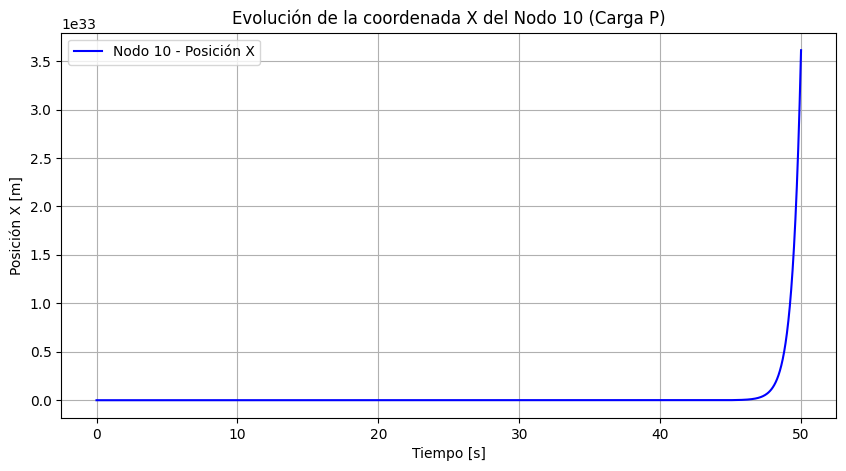

In [40]:


# --- 8. EXTRACCIÓN Y GRÁFICO DEL NODO 10 ---
# Extraemos la fila 18 de la matriz de resultados
posicion_x_nodo10 = resultados_Y[18, :]

plt.figure(figsize=(10, 5))
plt.plot(tiempo_simulado, posicion_x_nodo10, label='Nodo 10 - Posición X', color='blue')
plt.title('Evolución de la coordenada X del Nodo 10 (Carga P)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Posición X [m]')
plt.grid(True)
plt.legend()
plt.show()

### Parte B: Análisis y Comparación de Resultados

En cada una de estas dos situaciones ($a.i$ y $a.ii$), determine lo siguiente:

**i. Condición de Estado Límite (Intersección de barras)**
Las estructuras se diseñan o dimensionan para satisfacer condiciones de estado límite, que pueden corresponder a deformaciones (por ejemplo, un desplazamiento vertical, o flecha, máximo, de un elemento horizontal como una viga), resistencia (tensiones admisibles o tensiones últimas, como la tensión de fluencia en metales), estabilidad, entre otras. 
* En este ejercicio se adopta como condición límite el **cambio de signo del área de los triángulos cerrados** formados por las barras. Esta situación representa la condición en que las barras se cruzan, lo cual no es físicamente admisible si el movimiento ocurre en el plano. 
* Entonces, se debe determinar para las dos situaciones ($a.i$ y $a.ii$), el primer instante $t_F$ en el que se produce dicho cambio de signo en cualquiera de los triángulos que conforman la geometría de la estructura. 
> *Nota:* Si se supera $t_{F\_Max}$, adoptar que $t_F = t_{F\_Max}$.

**ii. Gráficas de Evolución Temporal**
Obtenga una gráfica de la evolución, hasta el tiempo $t_{Fa.i}$ o $t_{Fa.ii}$ según corresponda, de:
* La **tensión normal** (componente normal a la sección transversal) de la barra $a$.
* La **tensión tangencial** (componente contenida en el plano de la sección transversal) de la barra $a$.
* La **coordenada actual** del nodo $b$.

**Pregunta de análisis:** ¿Qué ocurre con la tensión tangencial y por qué?

**iii. Desplazamientos y Conclusiones Finales**
* Determine, en el intervalo $0$ a $\min(t_{Fa.i}, t_{Fa.ii})$, la **norma del vector desplazamiento máxima** entre todos los nodos y el instante en que se alcanza dicho valor. 
* **Compare** la evolución de las tensiones y de la coordenada actual obtenidas para ambas situaciones ($a.i$ y $a.ii$). 
* **Extraiga conclusiones** de las diferencias observadas: indique cuál sería el modelo más adecuado para el problema considerado y en qué intervalo temporal se podría aplicar uno u otro.

### Parte C: Incorporación de Dispositivo Amortiguador

Modifique el programa desarrollado para la situación $a.i$ (dirección de las fuerzas en la configuración deformada) para incorporar, en el nodo $c$, una esfera sólida de radio $r_{esf}$ que se desplaza dentro de un dispositivo constituido por un recipiente con líquido y aire (ver esquema en figura correspondiente). 

Este dispositivo actúa como un **mecanismo amortiguador** del movimiento de la esfera y, por lo tanto, del reticulado. 

![fluido](Imagenes/fluido.png)


**Simplificaciones:**
* Se considera únicamente la acción en la **dirección vertical** (despreciando la resistencia del fluido en dirección horizontal y al giro). 
* Se adopta que la fuerza generada por el contacto de la esfera con el aire en el dispositivo es despreciable.

**Cálculo de la Fuerza de Arrastre (Drag Force)**
Esta acción se entiende como una fuerza externa aplicada al sistema del reticulado y se calcula como:

$$F_a = -\frac{1}{2} \rho_{fl} C_d A_R |u| u$$

Donde:
* $\rho_{fl}$: Densidad del fluido.
* $C_d$: Coeficiente de arrastre, que depende de la forma del objeto (esfera) y del número de Reynolds ($Re$). Para un régimen de flujo de aproximadamente $10^3 < Re < 2 \times 10^5$, **se adopta $C_d$ constante e igual a $0.47$**.
* $A_R$: Superficie de referencia, que es la proyección de la parte sumergida en un plano perpendicular al movimiento.
* $u$: Velocidad de la esfera en dirección vertical.

**Condiciones de Inmersión (Área $A_R$)**
Esta área define una etapa de transición en el valor de la fuerza. Se deben considerar tres condiciones sobre la esfera dependiendo de su nivel de inmersión (asumiendo que esto no modifica el $C_d$ adoptado):
1. Esfera **completamente fuera** del fluido.
2. Esfera **parcialmente sumergida**, desde un polo hasta la mitad.
3. Esfera sumergida **desde la mitad y hasta su inmersión completa**.

> *Nota:* Esta transición contribuye a la robustez de la resolución numérica. El nivel de la superficie libre del fluido es fijo y está dado por la cota $h_{SL}$.

---

### Análisis de Resultados con Amortiguador

En el problema con el dispositivo amortiguador, analice lo siguiente:

**1. Comparaciones:**
* Compare los resultados de $t_F$ obtenidos (con y sin amortiguador).
* Compare la evolución temporal de la **tensión en la barra $a$**.
* Compare la evolución de la **coordenada actual del nodo $b$**.
* Compare la **norma del vector desplazamiento máxima** y el instante en que se produce.

**2. Conclusiones y Experimentación:**
* **¿Qué efecto tiene el dispositivo de amortiguamiento en la deformación de la estructura a lo largo del tiempo?**
* **Experimente y grafique** resultados convenientes variando los parámetros $r_{esf}$ y $\rho_{fl}$ para analizar su influencia en el problema.

### Parte D: Animación de Resultados

[cite_start]Realizar las animaciones de las respuestas de las estructuras (deformada en el tiempo) del **caso $a.i$**[cite: 48, 49]:
* **Sin amortiguamiento** (situación original).
* [cite_start]**Con amortiguamiento** (incorporando el dispositivo del punto c)[cite: 49].

In [41]:
%%latex
\begin{align}
\nabla \cdot \mathbf{E} &= \frac{\rho}{\varepsilon_0} \\
\nabla \cdot \mathbf{B} &= 0
\end{align}

<IPython.core.display.Latex object>